In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import (
    Adam,
    RMSprop
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import os

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
X_train_pad = np.load(
    "/content/drive/MyDrive/processed_data/X_train.npy"
)

X_val_pad = np.load(
    "/content/drive/MyDrive/processed_data/X_val.npy"
)

X_test_pad = np.load(
    "/content/drive/MyDrive/processed_data/X_test.npy"
)

y_train = np.load(
    "/content/drive/MyDrive/processed_data/y_train.npy"
)

y_val = np.load(
    "/content/drive/MyDrive/processed_data/y_val.npy"
)

y_test = np.load(
    "/content/drive/MyDrive/processed_data/y_test.npy"
)

In [4]:
print("Training:", X_train_pad.shape)
print("Validation:", X_val_pad.shape)
print("Testing:", X_test_pad.shape)

Training: (34998, 200)
Validation: (7502, 200)
Testing: (7500, 200)


In [5]:
VOCAB_SIZE = 20000

BASE_SEQUENCE_LENGTH = 200

BASE_EMBEDDING_DIM = 128

BASE_HIDDEN_UNITS = 64

BASE_DROPOUT = 0.3

BASE_BATCH_SIZE = 64

BASE_EPOCHS = 10

In [6]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    probabilities = model.predict(
        X_test,
        verbose=0
    ).flatten()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    print("\n", model_name)

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [9]:
#Build Baseline RNN
def build_baseline_RNN():

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        SimpleRNN(
            64
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            0.3
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [10]:
#Train Baseline RNN
baseline_RNN = build_baseline_RNN()

baseline_history = baseline_RNN.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4985 - loss: 0.6968 - val_accuracy: 0.5003 - val_loss: 0.6930
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5300 - loss: 0.6862 - val_accuracy: 0.5437 - val_loss: 0.6875
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.6145 - loss: 0.6116 - val_accuracy: 0.5714 - val_loss: 0.6929
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.6735 - loss: 0.4993 - val_accuracy: 0.5421 - val_loss: 0.8083
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7050 - loss: 0.4321 - val_accuracy: 0.5669 - val_loss: 0.9414


In [11]:
#Evaluate Baseline RNN
baseline_result = evaluate_model(

    baseline_RNN,

    X_test_pad,

    y_test,

    "Baseline RNN"
)


 Baseline RNN
Accuracy: 0.5611
Precision: 0.5397
Recall: 0.8293
F1 Score: 0.6539
ROC-AUC: 0.6043


In [12]:
os.makedirs(
    "saved_models",
    exist_ok=True
)

baseline_RNN.save(
    "saved_models/baseline_RNN.keras"
)

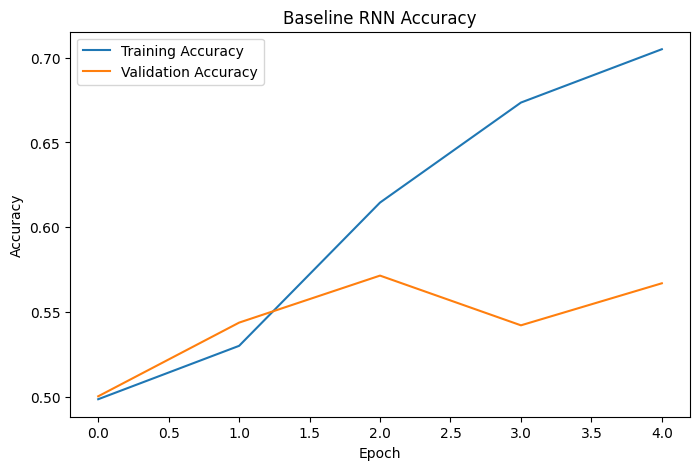

In [13]:
#Plot Baseline Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Baseline RNN Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [14]:
embedding_results = []

for embedding_dim in [64, 128, 256]:

    print(
        "\nTesting Embedding Dimension:",
        embedding_dim
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=embedding_dim,
            input_length=200
        ),

        SimpleRNN(64),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    val_accuracy = max(
        history.history["val_accuracy"]
    )

    embedding_results.append({

        "Embedding Dimension": embedding_dim,

        "Validation Accuracy": val_accuracy

    })


Testing Embedding Dimension: 64
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.5033 - loss: 0.6963 - val_accuracy: 0.5052 - val_loss: 0.6929
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5294 - loss: 0.6893 - val_accuracy: 0.5287 - val_loss: 0.6849
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.5863 - loss: 0.6477 - val_accuracy: 0.5264 - val_loss: 0.7215

Testing Embedding Dimension: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.5063 - loss: 0.6949 - val_accuracy: 0.5035 - val_loss: 0.6932
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5488 - loss: 0.6791 - val_accuracy: 0.5476 - val_loss: 0.6837
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6406 - loss: 0.5694 - val_accuracy: 0.5392 - val_loss: 0.7139

Testing Embedding Dimension: 256
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.4971 - loss: 0.6945 - val_accuracy: 0.4983 - val_loss: 0.6932
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 

In [15]:
embedding_df = pd.DataFrame(
    embedding_results
)

embedding_df

,Embedding Dimension,Validation Accuracy
0,64,0.528659
1,128,0.547587
2,256,0.511197


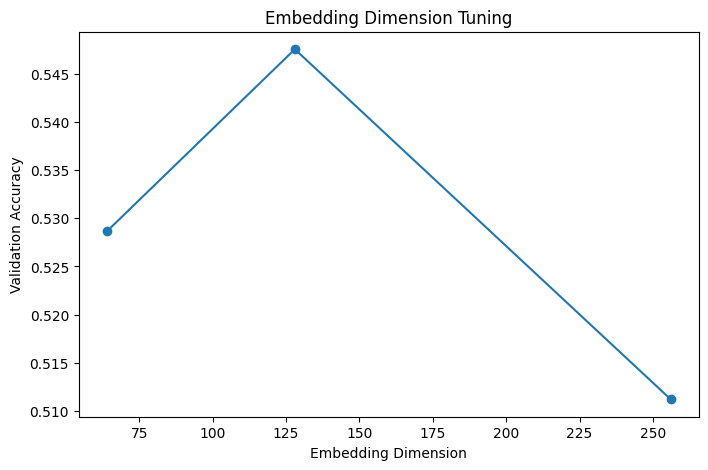

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    embedding_df["Embedding Dimension"],
    embedding_df["Validation Accuracy"],
    marker="o"
)

plt.title(
    "Embedding Dimension Tuning"
)

plt.xlabel(
    "Embedding Dimension"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.show()

In [17]:
hidden_results = []

for units in [32, 64, 128]:

    print(
        "\nTesting Hidden Units:",
        units
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        SimpleRNN(
            units
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    hidden_results.append({

        "Hidden Units": units,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Hidden Units: 32
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5013 - loss: 0.6946 - val_accuracy: 0.5225 - val_loss: 0.6918
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5946 - loss: 0.6530 - val_accuracy: 0.5028 - val_loss: 0.6942
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6650 - loss: 0.5409 - val_accuracy: 0.5169 - val_loss: 0.8222

Testing Hidden Units: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5008 - loss: 0.6941 - val_accuracy: 0.5157 - val_loss: 0.6928
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5078 - loss: 0.6978 - val_accuracy: 0.5021 - val_loss: 0.6957
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5035 - loss: 0.6945 - val_accuracy: 0.5024 - val_loss: 0.6936

Testing Hidden Units: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5020 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - a

In [18]:
hidden_df = pd.DataFrame(
    hidden_results
)

hidden_df

,Hidden Units,Validation Accuracy
0,32,0.522527
1,64,0.515729
2,128,0.507065


In [19]:
#Tune Dropout
dropout_results = []

for dropout_rate in [0.2, 0.3, 0.5]:

    print(
        "\nTesting Dropout:",
        dropout_rate
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        SimpleRNN(64),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            dropout_rate
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    dropout_results.append({

        "Dropout": dropout_rate,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Dropout: 0.2
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5011 - loss: 0.6963 - val_accuracy: 0.5077 - val_loss: 0.6945
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5294 - loss: 0.6875 - val_accuracy: 0.5421 - val_loss: 0.6811
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6124 - loss: 0.6124 - val_accuracy: 0.5069 - val_loss: 0.7379

Testing Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.5039 - loss: 0.6945 - val_accuracy: 0.5001 - val_loss: 0.6932
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5255 - loss: 0.6894 - val_accuracy: 0.5091 - val_loss: 0.6994
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5741 - loss: 0.6525 - val_accuracy: 0.5407 - val_loss: 0.7098

Testing Dropout: 0.5
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5031 - loss: 0.6947 - val_accuracy: 0.5055 - val_loss: 0.6931
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy

In [20]:
#Display Dropout Results
dropout_df = pd.DataFrame(
    dropout_results
)

dropout_df

,Dropout,Validation Accuracy
0,0.2,0.542122
1,0.3,0.540656
2,0.5,0.505465


In [21]:
#Tune Recurrent Dropout
recurrent_results = []

for recurrent_dropout in [0.0, 0.2, 0.3]:

    print(
        "\nTesting Recurrent Dropout:",
        recurrent_dropout
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        SimpleRNN(
            64,
            dropout=0.3,
            recurrent_dropout=recurrent_dropout
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    recurrent_results.append({

        "Recurrent Dropout":
            recurrent_dropout,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Recurrent Dropout: 0.0
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5039 - loss: 0.6950 - val_accuracy: 0.5200 - val_loss: 0.6899
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5583 - loss: 0.6742 - val_accuracy: 0.5281 - val_loss: 0.6991
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6355 - loss: 0.5807 - val_accuracy: 0.5463 - val_loss: 0.6889

Testing Recurrent Dropout: 0.2
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.5025 - loss: 0.7059 - val_accuracy: 0.5047 - val_loss: 0.6939
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5091 - loss: 0.6957 - val_accuracy: 0.5001 - val_loss: 0.6942
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.4962 - loss: 0.6957 - val_accuracy: 0.5043 - val_loss: 0.6938

Testing Recurrent Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.4991 - loss: 0.7046 - val_accuracy: 0.5159 - val_loss: 0.6929
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 

In [44]:
recurrent_df = pd.DataFrame(
    recurrent_results
)

recurrent_df

,Recurrent Dropout,Validation Accuracy
0,0.0,0.546254
1,0.2,0.504665
2,0.3,0.515862


In [22]:
#Try Batch Normalization
batchnorm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),

    SimpleRNN(
        64,
        dropout=0.3
    ),

    BatchNormalization(),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [23]:
batchnorm_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [24]:
batchnorm_history = batchnorm_model.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.4993 - loss: 0.7049 - val_accuracy: 0.5013 - val_loss: 0.6932
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5338 - loss: 0.6884 - val_accuracy: 0.5171 - val_loss: 0.6990
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6125 - loss: 0.6276 - val_accuracy: 0.5249 - val_loss: 0.7263
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6644 - loss: 0.5487 - val_accuracy: 0.5113 - val_loss: 0.8180
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6911 - loss: 0.4739 - val_accuracy: 0.5123 - val_loss: 1.3722


In [25]:
learning_rate_results = []

for lr in [0.001, 0.0005, 0.0001]:

    print(
        "\nTesting Learning Rate:",
        lr
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        SimpleRNN(
            64,
            dropout=0.3
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    optimizer = Adam(
        learning_rate=lr
    )

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    learning_rate_results.append({

        "Learning Rate": lr,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Learning Rate: 0.001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.5017 - loss: 0.6975 - val_accuracy: 0.5012 - val_loss: 0.6937
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5325 - loss: 0.6882 - val_accuracy: 0.5167 - val_loss: 0.6938
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5427 - loss: 0.6806 - val_accuracy: 0.5616 - val_loss: 0.6652

Testing Learning Rate: 0.0005
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.4996 - loss: 0.6946 - val_accuracy: 0.5031 - val_loss: 0.6932
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5367 - loss: 0.6867 - val_accuracy: 0.5205 - val_loss: 0.6918
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6265 - loss: 0.6011 - val_accuracy: 0.5956 - val_loss: 0.6843

Testing Learning Rate: 0.0001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.4978 - loss: 0.6959 - val_accuracy: 0.5087 - val_loss: 0.6930
Epoch

In [26]:
learning_rate_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_df

,Learning Rate,Validation Accuracy
0,0.0010,0.561584
1,0.0005,0.595574
2,0.0001,0.596641


In [27]:
optimizer_results = []

optimizers = {

    "Adam": Adam(
        learning_rate=0.0005
    ),

    "RMSprop": RMSprop(
        learning_rate=0.0005
    )
}


for optimizer_name, optimizer in optimizers.items():

    print(
        "\nTesting Optimizer:",
        optimizer_name
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        SimpleRNN(
            64,
            dropout=0.3
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    optimizer_results.append({

        "Optimizer": optimizer_name,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Optimizer: Adam
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.5020 - loss: 0.6951 - val_accuracy: 0.5077 - val_loss: 0.6932
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5461 - loss: 0.6833 - val_accuracy: 0.5203 - val_loss: 0.6889
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6342 - loss: 0.5934 - val_accuracy: 0.5387 - val_loss: 0.7311

Testing Optimizer: RMSprop
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.5040 - loss: 0.6944 - val_accuracy: 0.5095 - val_loss: 0.6930
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.5482 - loss: 0.6842 - val_accuracy: 0.5453 - val_loss: 0.7805
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.6422 - loss: 0.6468 - val_accuracy: 0.6453 - val_loss: 0.6510


In [28]:
optimizer_df = pd.DataFrame(
    optimizer_results
)

optimizer_df

,Optimizer,Validation Accuracy
0,Adam,0.538656
1,RMSprop,0.645295


In [29]:
batch_results = []

for batch_size in [32, 64, 128]:

    print(
        "\nTesting Batch Size:",
        batch_size
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        SimpleRNN(
            64,
            dropout=0.3
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.0005
        ),

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=batch_size,

        verbose=1
    )

    batch_results.append({

        "Batch Size": batch_size,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Batch Size: 32
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.4942 - loss: 0.6953 - val_accuracy: 0.5057 - val_loss: 0.6931
Epoch 2/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.5499 - loss: 0.6795 - val_accuracy: 0.5001 - val_loss: 0.7011
Epoch 3/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.6446 - loss: 0.5677 - val_accuracy: 0.5044 - val_loss: 0.7522

Testing Batch Size: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.4983 - loss: 0.6972 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5416 - loss: 0.6853 - val_accuracy: 0.5028 - val_loss: 0.6941
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6301 - loss: 0.6001 - val_accuracy: 0.5141 - val_loss: 0.7404

Testing Batch Size: 128
Epoch 1/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.5065 - loss: 0.6951 - val_accuracy: 0.4895 - val_loss: 0.6936
Epoch 2/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step 

In [30]:
batch_df = pd.DataFrame(
    batch_results
)

batch_df

,Batch Size,Validation Accuracy
0,32,0.505732
1,64,0.514130
2,128,0.516796


In [31]:
optimized_RNN = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),

    SimpleRNN(
        64,
        dropout=0.3,
        recurrent_dropout=0.2
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
optimized_optimizer = Adam(
    learning_rate=0.0005
)


optimized_RNN.compile(

    optimizer=optimized_optimizer,

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


optimized_RNN.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_22 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=2,

    restore_best_weights=True
)

In [34]:
learning_rate_scheduler = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=1,

    min_lr=0.00001
)

In [35]:
optimized_history = optimized_RNN.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping,
        learning_rate_scheduler
    ]
)
optimized_history = optimized_RNN.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping,
        learning_rate_scheduler
    ]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.5005 - loss: 0.7054 - val_accuracy: 0.4975 - val_loss: 0.6943 - learning_rate: 5.0000e-04
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.5010 - loss: 0.6978 - val_accuracy: 0.5071 - val_loss: 0.6934 - learning_rate: 5.0000e-04
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.4981 - loss: 0.6962 - val_accuracy: 0.5028 - val_loss: 0.6948 - learning_rate: 5.0000e-04
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5028 - loss: 0.6949 - val_accuracy: 0.4911 - val_loss: 0.6939 - learning_rate: 2.5000e-04
Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5075 - loss: 0.6956 - val_accuracy: 0.5061 - val_loss: 0.6932 - learning_rate: 1.2500e-04
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.4994 - loss: 0.6961 - val_accuracy: 0.5003 - val_loss: 0.6932 - learning_rate: 1.2500e-04
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/ste

In [36]:
optimized_RNN.save(
    "saved_models/optimized_RNN.keras"
)

print(
    "Optimized RNN saved successfully!"
)

Optimized RNN saved successfully!


In [37]:
optimized_result = evaluate_model(

    optimized_RNN,

    X_test_pad,

    y_test,

    "Optimized RNN"
)


 Optimized RNN
Accuracy: 0.4971
Precision: 0.4952
Recall: 0.3016
F1 Score: 0.3749
ROC-AUC: 0.4989


In [38]:
comparison = pd.DataFrame([

    baseline_result,

    optimized_result

])

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline RNN,0.5611,0.5397,0.8293,0.6539,0.6043
1,Optimized RNN,0.4971,0.4952,0.3016,0.3749,0.4989


In [39]:
accuracy_improvement = (

    optimized_result["Accuracy"]

    -

    baseline_result["Accuracy"]
)

f1_improvement = (

    optimized_result["F1 Score"]

    -

    baseline_result["F1 Score"]
)

roc_auc_improvement = (

    optimized_result["ROC-AUC"]

    -

    baseline_result["ROC-AUC"]
)


print(
    "Accuracy Improvement:",
    round(
        accuracy_improvement,
        4
    )
)

print(
    "F1 Score Improvement:",
    round(
        f1_improvement,
        4
    )
)

print(
    "ROC-AUC Improvement:",
    round(
        roc_auc_improvement,
        4
    )
)

Accuracy Improvement: -0.064
F1 Score Improvement: -0.279
ROC-AUC Improvement: -0.1055


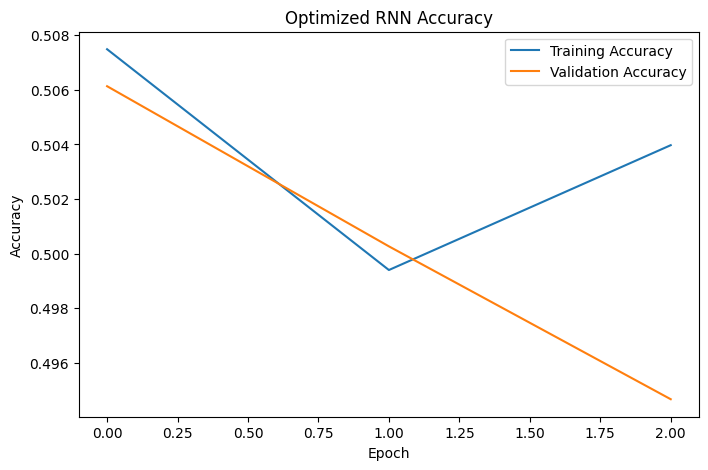

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "accuracy"
    ],

    label="Training Accuracy"
)

plt.plot(

    optimized_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"
)

plt.title(
    "Optimized RNN Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.show()

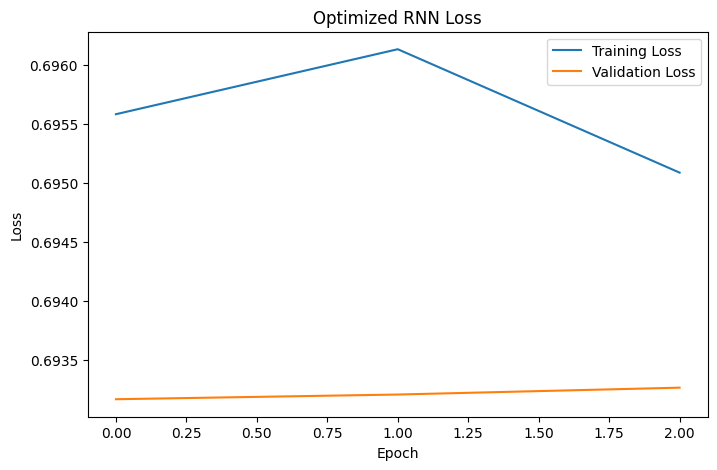

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "loss"
    ],

    label="Training Loss"
)

plt.plot(

    optimized_history.history[
        "val_loss"
    ],

    label="Validation Loss"
)

plt.title(
    "Optimized RNN Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()

In [45]:
embedding_df.to_csv(
    "saved_models/embedding_tuning.csv",
    index=False
)

hidden_df.to_csv(
    "saved_models/hidden_units_tuning.csv",
    index=False
)

dropout_df.to_csv(
    "saved_models/dropout_tuning.csv",
    index=False
)

recurrent_df.to_csv(
    "saved_models/recurrent_dropout_tuning.csv",
    index=False
)

learning_rate_df.to_csv(
    "saved_models/learning_rate_tuning.csv",
    index=False
)

optimizer_df.to_csv(
    "saved_models/optimizer_tuning.csv",
    index=False
)

batch_df.to_csv(
    "saved_models/batch_size_tuning.csv",
    index=False
)

comparison.to_csv(
    "saved_models/baseline_vs_optimized.csv",
    index=False
)

In [46]:
print("=" * 60)

print("PHASE 5 - MODEL IMPROVEMENT COMPLETED")

print("=" * 60)

print("\nBaseline RNN Accuracy:")

print(
    round(
        baseline_result["Accuracy"],
        4
    )
)

print("\nOptimized RNN Accuracy:")

print(
    round(
        optimized_result["Accuracy"],
        4
    )
)

print("\nAccuracy Improvement:")

print(
    round(
        accuracy_improvement,
        4
    )
)

print("\nBaseline F1 Score:")

print(
    round(
        baseline_result["F1 Score"],
        4
    )
)

print("\nOptimized F1 Score:")

print(
    round(
        optimized_result["F1 Score"],
        4
    )
)

print("\nF1 Improvement:")

print(
    round(
        f1_improvement,
        4
    )
)

print("\nOptimized Model Saved At:")

print(
    "saved_models/optimized_RNN.keras"
)

PHASE 5 - MODEL IMPROVEMENT COMPLETED

Baseline RNN Accuracy:
0.5611

Optimized RNN Accuracy:
0.4971

Accuracy Improvement:
-0.064

Baseline F1 Score:
0.6539

Optimized F1 Score:
0.3749

F1 Improvement:
-0.279

Optimized Model Saved At:
saved_models/optimized_RNN.keras
